In [3]:
import numpy as np
from scipy import integrate 
from scipy import interpolate
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [4]:
plt.style.use("fivethirtyeight")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Courier"
})

## Q2 Interpolation error

There are a large number of different interpolation schemes available through scipy.  Let's test them out.

Create a python function, $f(x)$, that is your true function (make it complicated!).  Now create $N$ samples of it (either regularly spaced or irregularly spaced).

Try some of the different interpolation routines.  `interpolate.interp1d` takes a `kind` argument that lets you choose the order of the interpolation.  Measure the error in the method, by comparing the interpolated result with the actual function value.  

Then do the same cubic splines (look at `CubicSpline`)

Plot the resulting interpolant.

In [5]:
def f(x):
    return x**3*np.sin(x)/(np.sqrt(x**(1/4) + np.arccosh(x)) + x**4*np.exp(x)/np.cos(x**2 + x))

In [25]:
N = 300

x = np.linspace(0,5,N)
y = f(x)

y_interp1 = interpolate.interp1d(x, y, kind = 'linear')
y_interp2 = interpolate.interp1d(x, y, kind = 'quadratic')
y_interp3 = interpolate.interp1d(x, y, kind = 'cubic')

/tmp/ipykernel_2722/4003094578.py:2: RuntimeWarning: invalid value encountered in arccosh
  return x**3*np.sin(x)/(np.sqrt(x**(1/4) + np.arccosh(x)) + x**4*np.exp(x)/np.cos(x**2 + x))


In [26]:
print(y_interp3(x))

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan na

/tmp/ipykernel_2722/4003094578.py:2: RuntimeWarning: invalid value encountered in arccosh
  return x**3*np.sin(x)/(np.sqrt(x**(1/4) + np.arccosh(x)) + x**4*np.exp(x)/np.cos(x**2 + x))


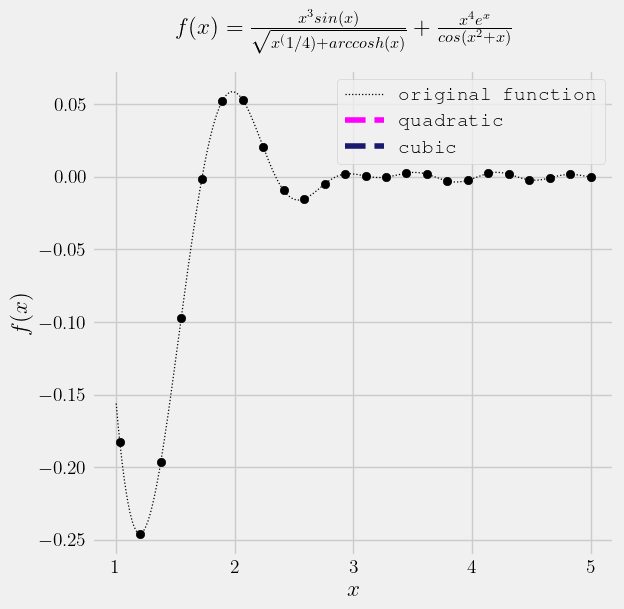

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
fig.suptitle(r"$ f(x) = \frac{x^3 sin(x)}{\sqrt{x^(1/4)+arccosh(x)}} + \frac{x^4 e^x}{cos(x^2 + x)}$")

x1 = np.linspace(x[0], x[-1], 10*N)

ax.scatter(x, y, color = "black")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.plot(x1, f(x1), ls=":",linewidth = 0.9, label="original function", color = "black")
ax.plot(x1, y_interp1(x1), ls="--", label="linear", color = "forestgreen")
ax.plot(x1, y_interp2(x1), ls="--", label="quadratic", color = "magenta")
ax.plot(x1, y_interp3(x1), ls="--", label="cubic", color = "midnightblue")
ax.legend()

In [19]:
help(ax.plot)

Help on method plot in module matplotlib.axes._axes:

plot(*args, scalex=True, scaley=True, data=None, **kwargs) method of matplotlib.axes._axes.Axes instance
    Plot y versus x as lines and/or markers.

    Call signatures::

        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

    The coordinates of the points or line nodes are given by *x*, *y*.

    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.

    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses

    You can use `.Line2D` properties as keyword arguments for more
    control on the appearance. Line properties and *fmt*

## Q5: Planetary orbits


\begin{align*}
\frac{dx}{dt} &= v_x \\
\frac{dy}{dt} &= v_y \\
\frac{dv_x}{dt} &= a_x = -\frac{GM_\star x}{r^3} \\
\frac{dv_y}{dt} &= a_y = -\frac{GM_\star y}{r^3}
\end{align*}

The distance of perihelion from the focus is:

$$r_p = a (1 - e)$$

where $a$ is the semi-major axis and $e$ is the eccentricity.  The perihelion velocity is all in the $y$ direction and is:

$$v_y = v_p = \sqrt{\frac{GM_\star}{a} \frac{1+e}{1-e}}$$

initial conditions:
  * $x(t=0) = r_p$
  * $y(t=0) = 0$
  * $v_x(t=0) = 0$
  * $v_y(t=0) = v_p$

$GM_\star = 4\pi^2$

Let's pretend we're tracking earth's orbit around the sun. The earth's trajectory around the sun is nearly circular, at a distance of 1 AU, but let's pretend for a while that it has a small measurable eccentricity

In [10]:
#eccentricity
e = 0
#semi major axis in AU 
a = 1.
#perihelion radius
rp = a*(1-e)

In [11]:
def rhs_func(t,X):
    xdot = X[2]
    ydot = X[3]
    r = np.sqrt(X[0]**2+X[1]**2)
    vx = - (4*np.pi**2/r**3)*X[0]
    vy = - (4*np.pi**2/r**3)*X[1]
    return np.array([xdot, ydot, vx, vy])

def jacob(t,X):
    r = np.sqrt(X[0]**2+X[1]**2)
    return np.array([0.,0.,1.,0], [0.,0.,0.,1.], 
                    [-4*np.pi**2/r**3,0.,0.,0.], 
                    [0.,-4*np.pi**2/r**3,0.,0.])

# these functions will later be used to make the integrator "remember" the t and (x,y,vx,vy) quantities everytime 
# x = rp and y = 0, so it trackes everytime the earth crosses the perihelion radius or everytime it crosses 
# y = 0 which happens twice per orbit. 

def perihelion_cross(t,X):
    return X[0]-rp

def half_orbits(t,X):
    return X[1]


In [12]:
#initial conditions
X0 = np.array([ rp, 0., 0., np.sqrt((4*np.pi**2/a)*((1+e)/(1-e))) ])

#final time of integration in years
tmax = 15

earth_trajectory = integrate.solve_ivp(rhs_func, (0.0, tmax), X0, dense_output=True, vectorized = True, 
                                       jac = jacob, events=(perihelion_cross, half_orbits))

#the minus one in the number of crosses is just to ignore the initial position
print(f"In {tmax:.1f} years, the earth orbits around the sun exactly {len(earth_trajectory.t_events[1])//2} times",
        f"and crosses the perihelion exactly {len(earth_trajectory.t_events[0])-1} times.")

/home/matildeg02/pycbc-env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `jac`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


In 15.0 years, the earth orbits around the sun exactly 302 times and crosses the perihelion exactly 0 times.


I really don't know what I could be doing wrong, but this is not even a trajectory, and nothing even changes when I change the eccentricity. Something is clearly off 

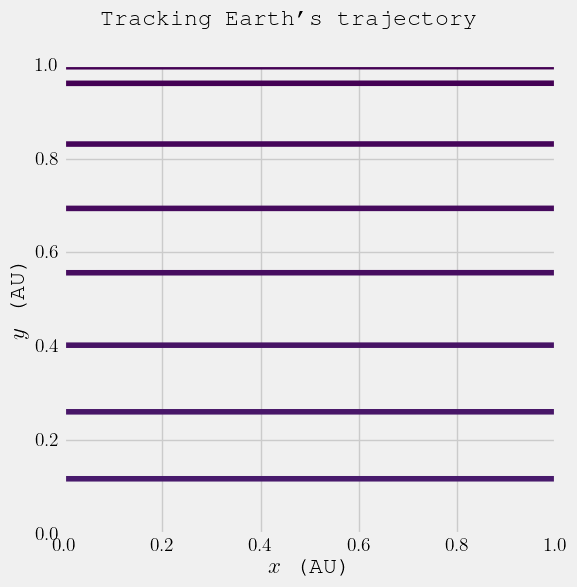

In [13]:
fig = plt.figure(figsize=(6,6))
fig.suptitle(r"Tracking Earth's trajectory")
ax = fig.add_subplot(111)
ax.contour([earth_trajectory.sol(earth_trajectory.t)[0], earth_trajectory.sol(earth_trajectory.t)[1]], earth_trajectory.t)
ax.set_xlabel(r"$x$ (AU)")
ax.set_ylabel(r"$y$ (AU)")
ax.set_xlim(0,1)
fig.tight_layout()
